ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons
k= 1  LOOCV acc=0.669  AUC=0.742
k= 2  LOOCV acc=0.661  AUC=0.771
k= 3  LOOCV acc=0.686  AUC=0.791
k= 5  LOOCV acc=0.678  AUC=0.792
k= 8  LOOCV acc=0.669  AUC=0.791
k=10  LOOCV acc=0.669  AUC=0.792
k=15  LOOCV acc=0.669  AUC=0.791
k=20  LOOCV acc=0.669  AUC=0.792
Best k by LOOCV accuracy: 3
[best_k=3] LOOCV acc=0.686, AUC=0.791


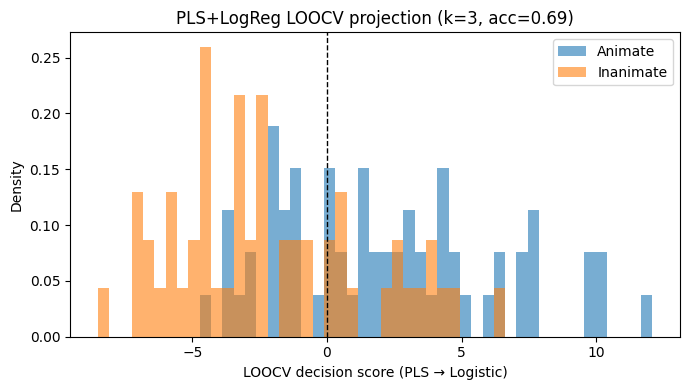

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Inputs you already have:
#   R      : (n_images, n_neurons)
#   labels : (n_images,) 0/1
# ------------------------------------------------------------

def pls_logreg_loocv(R, labels, n_components=5, C=1.0, max_iter=5000):
    loo = LeaveOneOut()

    y_true = []
    y_pred = []
    y_score = []

    for tr, te in loo.split(R):
        Xtr, Xte = R[tr], R[te]
        ytr, yte = labels[tr], labels[te]

        # 1) Standardize neurons using TRAIN only
        sc = StandardScaler(with_mean=True, with_std=True)
        Xtr_z = sc.fit_transform(Xtr)
        Xte_z = sc.transform(Xte)

        # 2) PLS: supervised DR (TRAIN only)
        # PLSRegression expects y as 2D
        pls = PLSRegression(n_components=n_components, scale=False)
        pls.fit(Xtr_z, ytr.reshape(-1, 1))

        Ztr = pls.transform(Xtr_z)  # (n_train, k)
        Zte = pls.transform(Xte_z)  # (1, k)

        # 3) Logistic regression on latent components
        clf = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=C,
            max_iter=max_iter
        )
        clf.fit(Ztr, ytr)

        score = clf.decision_function(Zte)[0]
        pred = int(score > 0)

        y_true.append(yte[0])
        y_pred.append(pred)
        y_score.append(score)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    acc = (y_true == y_pred).mean()
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    return acc, auc, y_true, y_pred, y_score

"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
labels = (top1 <= 397).astype(int)

# ------------------------------------------------------------
# Sweep number of PLS components
# ------------------------------------------------------------
k_list = [1, 2, 3, 5, 8, 10, 15, 20]
results = []

for k in k_list:
    acc, auc, y_true, y_pred, y_score = pls_logreg_loocv(R, labels, n_components=k, C=1.0)
    results.append((k, acc, auc))
    print(f"k={k:>2d}  LOOCV acc={acc:.3f}  AUC={auc:.3f}")

# Pick best k by accuracy (or AUC)
best_k = max(results, key=lambda t: t[1])[0]
print("Best k by LOOCV accuracy:", best_k)

# ------------------------------------------------------------
# Re-run at best_k to get scores for plotting
# ------------------------------------------------------------
acc, auc, y_true, y_pred, y_score = pls_logreg_loocv(R, labels, n_components=best_k, C=1.0)
print(f"[best_k={best_k}] LOOCV acc={acc:.3f}, AUC={auc:.3f}")

# ------------------------------------------------------------
# Plot label histograms on the LOOCV decision axis
# (each point scored by a model that did not train on it)
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
bins = np.linspace(y_score.min(), y_score.max(), 50)

plt.hist(y_score[y_true == 1], bins=bins, density=True, alpha=0.6, label="Animate")
plt.hist(y_score[y_true == 0], bins=bins, density=True, alpha=0.6, label="Inanimate")
plt.axvline(0, color="k", linestyle="--", linewidth=1)

plt.xlabel("LOOCV decision score (PLS → Logistic)")
plt.ylabel("Density")
plt.title(f"PLS+LogReg LOOCV projection (k={best_k}, acc={acc:.2f})")
plt.legend()
plt.tight_layout()
plt.show()
